In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load cleaned data
df = pd.read_csv('../data/processed/cleaned_data.csv')
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Rows:", df.shape[0])
print("Columns:", df.columns.tolist())

Rows: 805549
Columns: ['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country', 'TotalPrice']


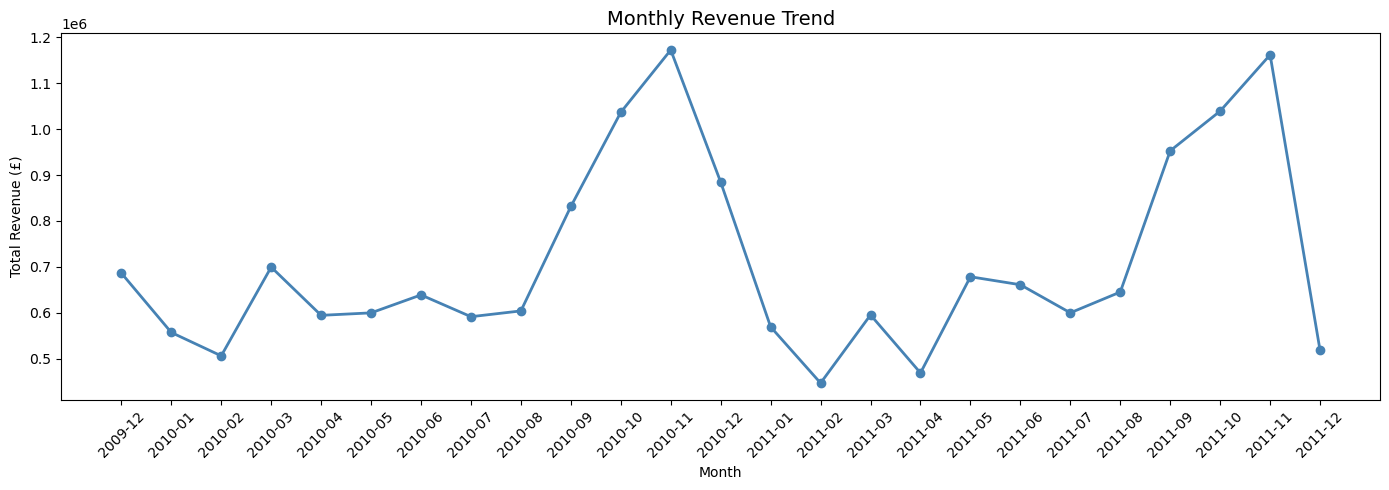

✅ Saved to outputs/chart_monthly_revenue.png


In [3]:
# Extract year and month
df['Month'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['TotalPrice'].sum().reset_index()
monthly_revenue['Month'] = monthly_revenue['Month'].astype(str)

plt.figure(figsize=(14, 5))
plt.plot(monthly_revenue['Month'], monthly_revenue['TotalPrice'], marker='o', color='steelblue', linewidth=2)
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('../outputs/chart_monthly_revenue.png')
plt.show()
print("✅ Saved to outputs/chart_monthly_revenue.png")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_15372\4027031301.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')


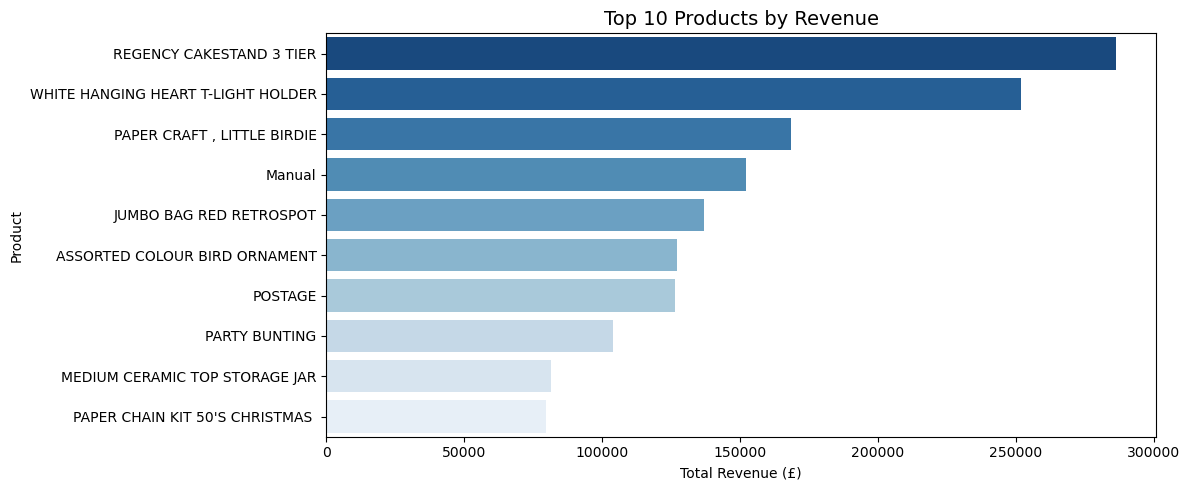

✅ Saved to outputs/chart_top_products.png


In [4]:
top_products = df.groupby('Description')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_products.values, y=top_products.index, palette='Blues_r')
plt.title('Top 10 Products by Revenue', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Product')
plt.tight_layout()
plt.savefig('../outputs/chart_top_products.png')
plt.show()
print("✅ Saved to outputs/chart_top_products.png")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_15372\4015344179.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='Greens_r')


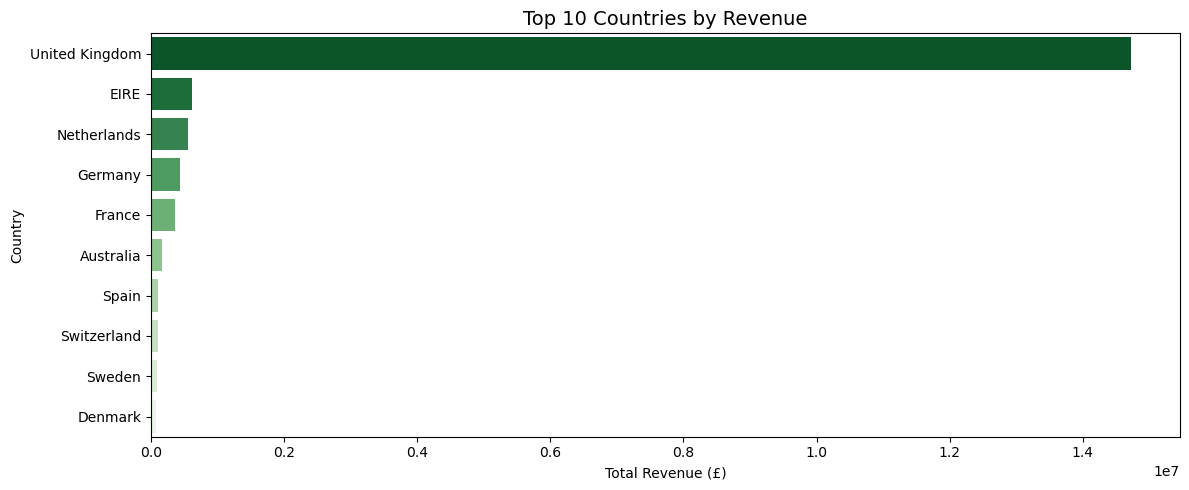

✅ Saved to outputs/chart_top_countries.png


In [5]:
top_countries = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_countries.values, y=top_countries.index, palette='Greens_r')
plt.title('Top 10 Countries by Revenue', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Country')
plt.tight_layout()
plt.savefig('../outputs/chart_top_countries.png')
plt.show()
print("✅ Saved to outputs/chart_top_countries.png")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_15372\624031217.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=day_revenue.index, y=day_revenue.values, palette='Oranges_r')


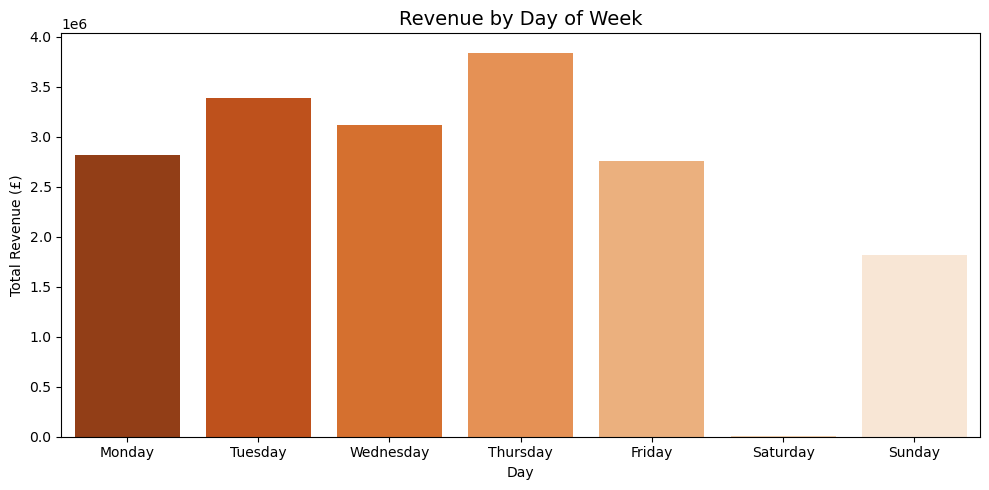

✅ Saved to outputs/chart_day_of_week.png


In [6]:
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_revenue = df.groupby('DayOfWeek')['TotalPrice'].sum().reindex(day_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=day_revenue.index, y=day_revenue.values, palette='Oranges_r')
plt.title('Revenue by Day of Week', fontsize=14)
plt.xlabel('Day')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('../outputs/chart_day_of_week.png')
plt.show()
print("✅ Saved to outputs/chart_day_of_week.png")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_15372\509435939.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=hour_revenue.index, y=hour_revenue.values, palette='Purples_r')


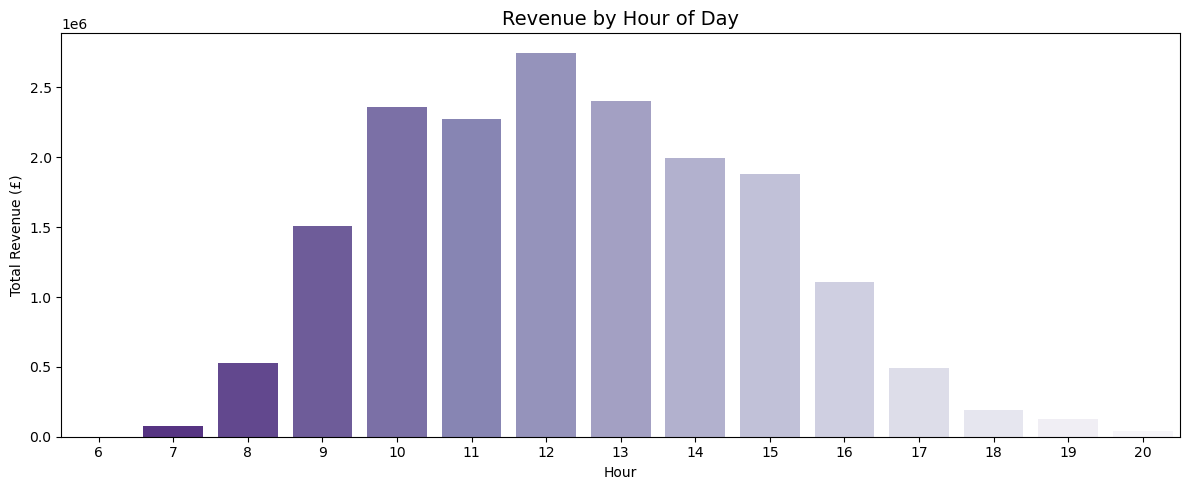

✅ Saved to outputs/chart_hour_of_day.png


In [7]:
df['Hour'] = df['InvoiceDate'].dt.hour

hour_revenue = df.groupby('Hour')['TotalPrice'].sum()

plt.figure(figsize=(12, 5))
sns.barplot(x=hour_revenue.index, y=hour_revenue.values, palette='Purples_r')
plt.title('Revenue by Hour of Day', fontsize=14)
plt.xlabel('Hour')
plt.ylabel('Total Revenue (£)')
plt.tight_layout()
plt.savefig('../outputs/chart_hour_of_day.png')
plt.show()
print("✅ Saved to outputs/chart_hour_of_day.png")

C:\Users\VICTUS\AppData\Local\Temp\ipykernel_15372\3020148832.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_customers.values, y=top_customers.index, palette='Reds_r')


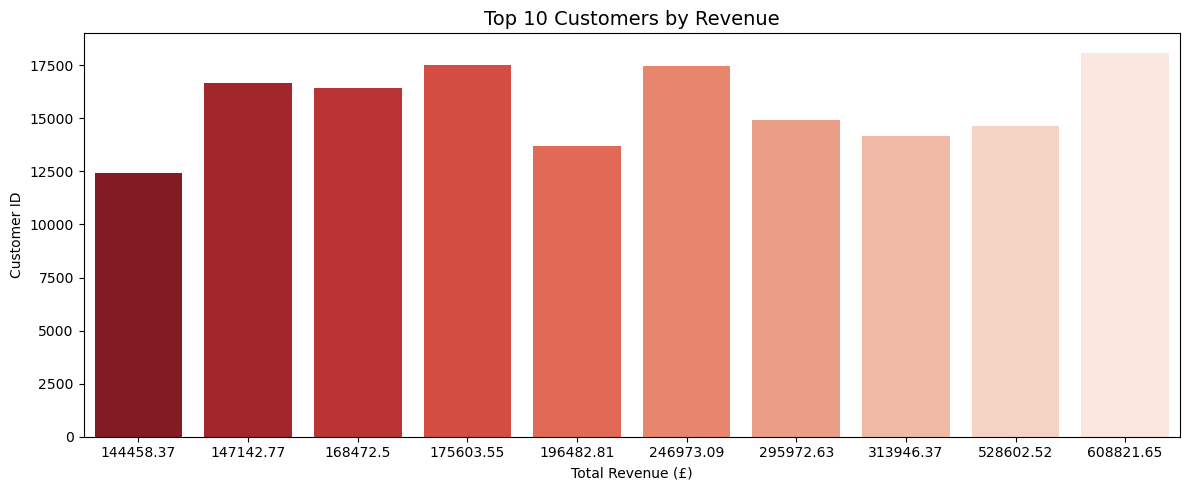

✅ Saved to outputs/chart_top_customers.png


In [8]:
top_customers = df.groupby('Customer ID')['TotalPrice'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12, 5))
sns.barplot(x=top_customers.values, y=top_customers.index, palette='Reds_r')
plt.title('Top 10 Customers by Revenue', fontsize=14)
plt.xlabel('Total Revenue (£)')
plt.ylabel('Customer ID')
plt.tight_layout()
plt.savefig('../outputs/chart_top_customers.png')
plt.show()
print("✅ Saved to outputs/chart_top_customers.png")

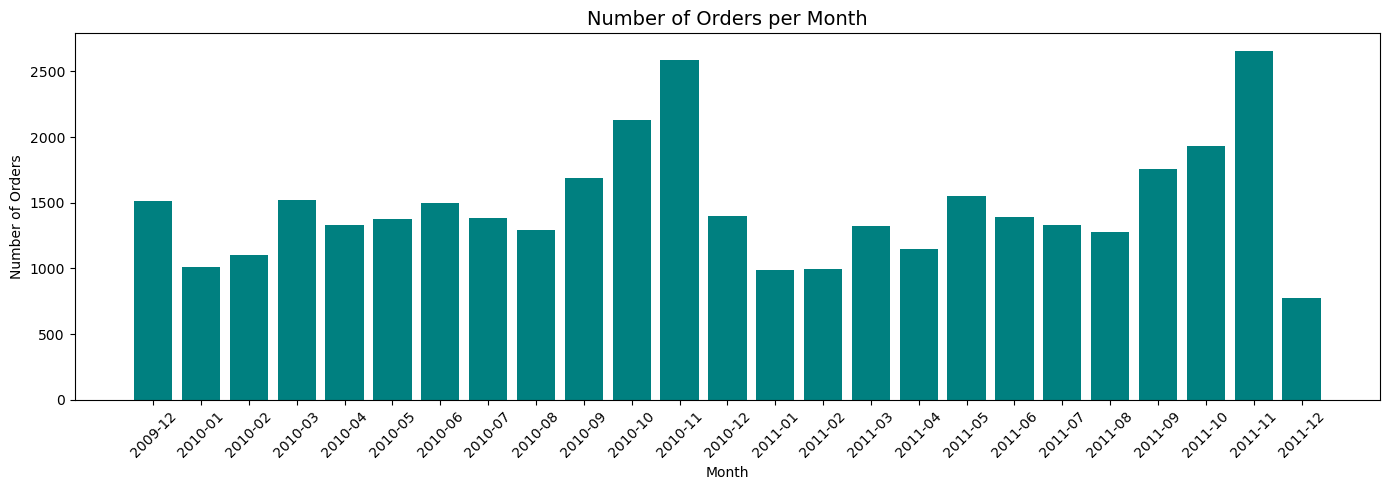

✅ Saved to outputs/chart_monthly_orders.png


In [9]:
monthly_orders = df.groupby('Month')['Invoice'].nunique().reset_index()
monthly_orders['Month'] = monthly_orders['Month'].astype(str)

plt.figure(figsize=(14, 5))
plt.bar(monthly_orders['Month'], monthly_orders['Invoice'], color='teal')
plt.xticks(rotation=45)
plt.title('Number of Orders per Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.savefig('../outputs/chart_monthly_orders.png')
plt.show()
print("✅ Saved to outputs/chart_monthly_orders.png")

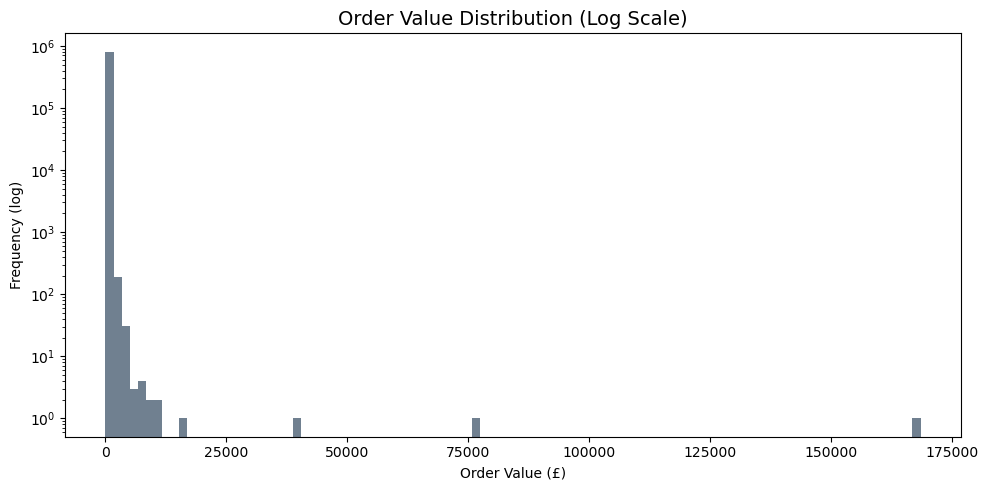

✅ Saved to outputs/chart_order_distribution.png


In [10]:
plt.figure(figsize=(10, 5))
df['TotalPrice'].apply(lambda x: x if x > 0 else None).dropna().plot(kind='hist', bins=100, color='slategray', log=True)
plt.title('Order Value Distribution (Log Scale)', fontsize=14)
plt.xlabel('Order Value (£)')
plt.ylabel('Frequency (log)')
plt.tight_layout()
plt.savefig('../outputs/chart_order_distribution.png')
plt.show()
print("✅ Saved to outputs/chart_order_distribution.png")

In [11]:
total_revenue = df['TotalPrice'].sum()
total_orders = df['Invoice'].nunique()
total_customers = df['Customer ID'].nunique()
aov = total_revenue / total_orders
top_country = df.groupby('Country')['TotalPrice'].sum().idxmax()
top_product = df.groupby('Description')['TotalPrice'].sum().idxmax()
best_month = monthly_revenue.loc[monthly_revenue['TotalPrice'].idxmax(), 'Month']

print("======= KEY BUSINESS INSIGHTS =======")
print(f"Total Revenue:         £{total_revenue:,.2f}")
print(f"Total Orders:          {total_orders:,}")
print(f"Unique Customers:      {total_customers:,}")
print(f"Average Order Value:   £{aov:,.2f}")
print(f"Top Country:           {top_country}")
print(f"Top Product:           {top_product}")
print(f"Best Month:            {best_month}")

======= KEY BUSINESS INSIGHTS =======
Total Revenue:         £17,743,429.18
Total Orders:          36,969
Unique Customers:      5,878
Average Order Value:   £479.95
Top Country:           United Kingdom
Top Product:           REGENCY CAKESTAND 3 TIER
Best Month:            2010-11
